Let $k\neq 0$, we consider the equation 
$$
\frac{d^2 y(\theta)}{d\theta^2} = k y(\theta) \tag{1}
$$   
on the circle $\mathbb{S}^1$, parametrized by $\theta \in [0,2\pi[$. We look for a smooth solution $y$ defined on $\mathbb{S}^1$.

A simple integration of $(1)$ gives
$$
    k \int_0^{2\pi} y(\theta) d\theta = \big[y'(\theta) \big]_0^{2\pi} = 0
$$
so that $y$ must be of zero-mean on $\mathbb{S}^1$. Moreover, multiplying by $y$ and integrating gives
$$
    k \int_0^{2\pi} y(\theta)^2 d\theta = \int_0^{2\pi} y''(\theta)y(\theta)d\theta = - \int_0^{2\pi} y'(\theta)^2 d\theta,
$$
so that $k$ must be negative, we write $k = -\alpha^2$.

Explicit solutions are given by 
$$
    y(\theta) = K_1 \cos(\alpha \theta) + K_2 \sin(\alpha \theta),
$$
for any constants $K_1,K_2 \in \mathbb{R}$. This implies the further condition that $\alpha \in \mathbb{Z}$ in order to satisfy the periodicity condition. The equation we consider thus becomes 
$$ 
    \frac{d^2 y(\theta)}{d\theta^2} = - \alpha^2 y(\theta) \tag{1'}
$$

We use that $\mathbb{S}^1 = \{(\cos\theta,\sin\theta)\in \mathbb{R}^2 \,:\, \theta \in [0,2\pi)\}$, so that we can write 
$$
    y(\theta) = g(\cos\theta,\sin\theta).
$$
Here $g$ is a function of two variables, $g(x_1,x_2), x_1, x_2 \in \mathbb{R}$ such that $x_1^2+x_2^2 = 1$. It follows that $y$ is a solution to $(1')$ if and only if $g$ satisfies
$$
    -x_1 \frac{\partial g}{\partial x_1} - x_2 \frac{\partial g}{\partial x_2} + x_2^2 \frac{\partial^2 g}{\partial x_1^2} - 2x_1x_2 \frac{\partial^2 g}{\partial x_1\partial x_2} + x_1^2 \frac{\partial^2 g}{\partial x_2^2} = -\alpha^2 g \qquad \text{for all $x_1^2+x_2^2 = 1$}.
    \tag{2}
$$
This follows from the fact that 
$$\begin{aligned}
    \frac{dy(\theta)}{d\theta} &= \frac{d}{d\theta}\Big(g(\cos\theta,\sin\theta)\Big) = -\sin(\theta) \frac{\partial g}{\partial x_1} (\cos\theta,\sin\theta)+ \cos\theta \frac{\partial g}{\partial x_2} (\cos\theta,\sin\theta)\\
    \frac{d^2y(\theta)}{d\theta^2} &= -\cos\theta \frac{\partial g}{\partial x_1}(\cos\theta,\sin\theta) + \sin^2\theta \frac{\partial^2 g}{\partial x_1^2}(\cos\theta,\sin\theta) - \sin\theta\cos\theta \frac{\partial^2 g}{\partial x_1\partial x_2}(\cos\theta,\sin\theta)\\
    & \qquad - \sin\theta \frac{\partial g}{\partial x_2}(\cos\theta,\sin\theta) - \cos\theta\sin\theta \frac{\partial^2 g}{\partial x_1 \partial x_2}(\cos\theta,\sin\theta) + \cos^2\theta \frac{\partial^2 g}{\partial x_2^2}(\cos\theta,\sin\theta)
\end{aligned}$$

The goal is therefore to train a neural network with 2 real entries between $-1$ and $1$ and one real output, to minimize the pde_loss of $(2)$. One can impose in addition the soft condition $\int_0^{2\pi} |g(\cos\theta, \sin\theta)|^2 d\theta = 1$ to ensure that the trivial solution is excluded, which gives the family of explicit solutions 
$$
    y(\theta) = K \cos(\alpha\theta) \pm \sqrt{\tfrac{1}{\pi}-K^2}\, \sin(\alpha \theta),
$$
for any $K\in [-\frac{1}{\sqrt{\pi}},\frac{1}{\sqrt{\pi}}]$.

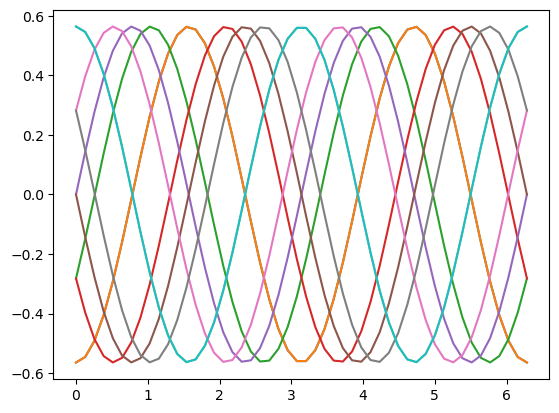

In [1]:
import matplotlib.pyplot as plt
import numpy as np

a = 2
overpi = 1/np.pi
ts = np.linspace(0,2*np.pi)
Ks = np.linspace(-1/np.sqrt(np.pi),1/np.sqrt(np.pi), 5)

for k in Ks:
    k2 = np.sqrt(overpi - k**2)
    plt.plot(ts, k* np.cos(a*ts)+ k2 *np.sin(a*ts), label =f"+({k},{k2})")
    plt.plot(ts, k * np.cos(a*ts)- k2 * np.sin(a*ts), label =f"-({k},{k2})")


All these solutions actually correspond to the same ground state 
$$
    y_0(\theta) = \frac{1}{\sqrt{\pi}} \cos(\alpha\theta)
$$
and its offsets 
$$
    y_0(\theta+\theta_0) = \frac{1}{\sqrt{\pi}} \cos(\alpha(\theta+\theta_0)),\quad \theta_0 \in [0,2\pi).
$$

---

Let now $p>2$ be fixed, we consider the non-linear equation
$$
    y'' = k\, y|y|^{p-2} \tag{3}
$$
on the circle $\mathbb{S}^1$. As before, integrating (1) shows that $y$ must necessarily be sign-changing on $\mathbb{S}^1$, and multiplying by $y$ and integrating shows that
$$
    \int_0^{2\pi} y'(\theta)d\theta = -k\int_0^{2\pi} |y(\theta)|^p d\theta\tag{4},
$$
so that $k<0$. Now observe that if $y_k$ is a solution to (3), then $|k|^{\frac{1}{p-2}}\,y_k$ is a solution to 
$$ 
    -y'' = y|y|^{p-2} \tag{3'}.
$$
We thus only study equation (3'), since solutions for other $k$s can be obtained by simple scaling of solutions to (3')

It is immediate to see that (3') is a conservative system : Multiplying by $y'$ and taking primitives shows that 
$$
    \frac{1}{2}(y')^2 + \frac{1}{p}|y|^p = e^2,
$$
the pointwise energy $e^2>0$ is a conserved quantity along $\theta\in [0,2\pi)$. The phase space of the solutions thus looks like the following.

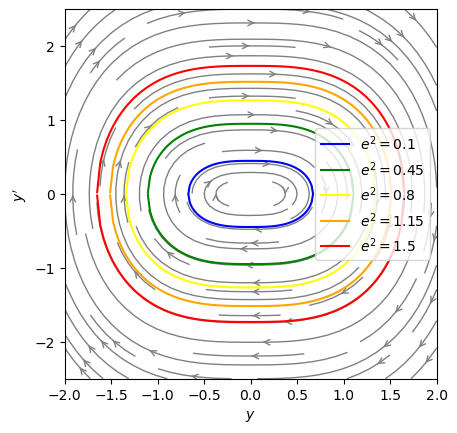

In [2]:
p = 3

x, y = np.meshgrid(np.linspace(-2,2,100),np.linspace(-2.5,2.5,100))
u, v = y, -x*np.abs(x)**(p-2)
plt.figure(figsize = plt.figaspect(1))
plt.streamplot(x, y, u, v,color='gray', linewidth=1, arrowstyle='->')

colors = ["blue","green","yellow","orange","red"]
i = 0
for e in np.linspace(0.1,1.5, 5):
    ys = np.linspace(-(p*e)**(1/p)+1e-4,(p*e)**(1/p)-1e-4,100)
    plt.plot(ys,np.sqrt(2*(e-1/p * np.abs(ys)**p)), color = colors[i], label = f"$e^2 = {np.round(e,2)}$")
    plt.plot(ys,-np.sqrt(2*(e-1/p * np.abs(ys)**p)),color = colors[i])
    i+=1
plt.legend()
plt.xlabel("$y$")
plt.ylabel("$y'$")
plt.show()

The condition of periodicity moreover imposes a quantification of the energy, as a point $(y(\theta),y'(\theta))$ in the phase space must have done an integer number of complete turns between any $\theta_0$ and $\theta_0+2\pi$. This means that there exists $\alpha\in \mathbb{N}$ such that 
\begin{align}  
    \frac{\pi}{\alpha} &= \int_{-y_0}^{y_0} \frac{dy}{\sqrt{2e^2-\tfrac{2}{p}|y|^p}}, \qquad y_0 := (pe^2)^{1/p}\\
        &= \sqrt{2p} \int_{0}^{y_0} \frac{dy}{\sqrt{y_0^p - y^p}} = \sqrt{2}p^{1/p}(e^2)^{-\frac{p-2}{2p}} \int_0^1 \frac{dy}{\sqrt{1-y^p}}
\end{align}
$$
    \Rightarrow e^2 = \kappa\, \alpha^{\frac{2p}{p-2}}, \qquad \text{for } \kappa := \left(\frac{\sqrt{2}}{\pi} p^{1/p} \int_0^1 \frac{dy}{\sqrt{1-y^p}}\right)^{\frac{2p}{p-2}}, \qquad \alpha \in \mathbb{N}.
$$
Standard existence results for ODEs give the existence of global solutions, but only some of them will be $2\pi$-periodic. There is no reason for one solution to be of $L^2$-norm 1.

In fact, using (4), we get that if $y_\alpha$ is a solution of (3') on $\mathbb{S}^1$ with energy $e^2_\alpha = \kappa\, \alpha^{\frac{2p}{p-2}}$, then
$$
    \frac{p+2}{2p} \int_0^{2\pi}|y_\alpha(\theta)|^p d\theta = 2\pi\kappa \alpha^{\frac{2p}{p-2}}.
$$
Thus, the smallest non-trivial solution (corresponding to $\alpha = 1$) satisfies $\|y_1\|_{L^p}^p = \frac{2p}{p+2} 2\pi \kappa$ (see the numerical integration below).

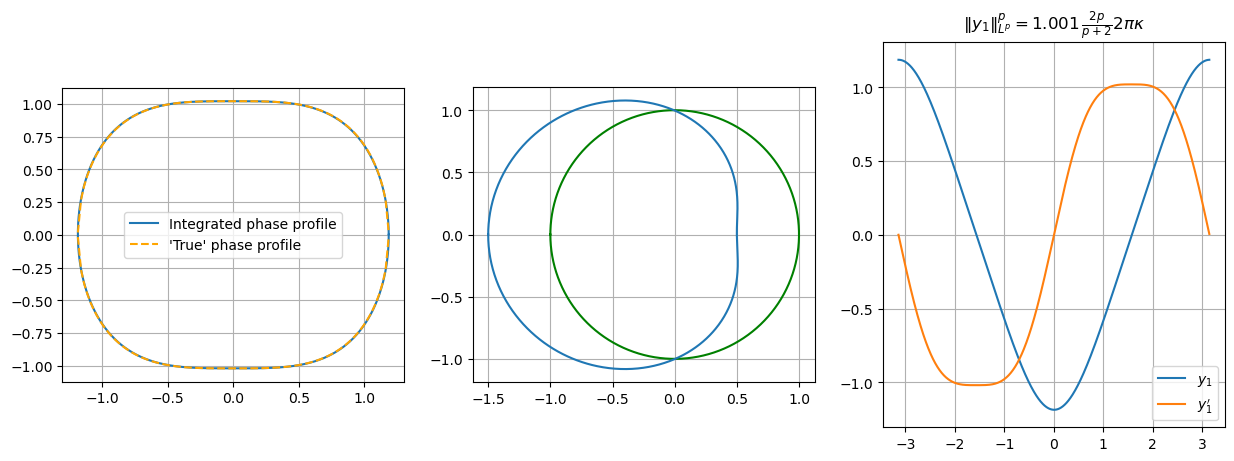

In [208]:
p = 3.5

alpha = 1

kappa_alpha = (np.sqrt(2)/np.pi * p**(1/p) * (1/np.sqrt(1-np.linspace(0,1,1000000, endpoint= False)**p)).mean() * alpha)**(2*p/(p-2))

# aa = np.arange(1,6)
# plt.plot(aa, 2*p/(p+2)*2*np.pi*kappa_alpha* aa**(2*p/(p-2)), "-o")
# plt.suptitle("$\\|y_\\alpha\\|_{L^p}^p$, $\\alpha = 1,\\ldots, 5$")
# plt.grid(True)
# plt.show()

def integrate(y0, yp0, time_splits):
    y = [y0]
    yp = [yp0]
    for i in range(1,time_splits.shape[0]):
        dt = time_splits[i]-time_splits[i-1]
        y.append(y[-1] + yp[-1] * dt)
        yp.append(yp[-1] - y[-1]*np.abs(y[-1])**(p-2) * dt)
    return np.array(y), np.array(yp)


thetas = np.linspace(-np.pi,np.pi, 1000)

fig, ax = plt.subplots(1,3, figsize = (15,5))
y, yp = integrate((p*kappa_alpha)**(1/p), 0, thetas)

ax[0].plot(y,yp, label = "Integrated phase profile")

ys = np.linspace(-(p*kappa_alpha)**(1/p)+1e-4,(p*kappa_alpha)**(1/p)-1e-4,100)
ax[0].plot(ys,np.sqrt(2*(kappa_alpha-1/p * np.abs(ys)**p)), color = "orange", linestyle = "dashed", label = "'True' phase profile")
ax[0].plot(ys,-np.sqrt(2*(kappa_alpha-1/p * np.abs(ys)**p)),color = "orange", linestyle = "dashed")

ax[0].legend()
ax[0].grid()
ax[0].set_aspect("equal")


max_y = 2*np.max(np.abs(y))
ax[1].plot(np.cos(thetas), np.sin(thetas), color = "green")
ax[1].plot(np.cos(thetas) * (1+y/max_y), np.sin(thetas) * (1+y/max_y))
ax[1].set_aspect("equal")
ax[1].grid()

ax[2].plot(thetas, y, label = "$y_"+str(alpha)+"$")
ax[2].plot(thetas, yp, label = "$y_"+str(alpha)+"'$")
ax[2].legend()
ax[2].grid()

ax[2].set_title("$\\|y_"+str(alpha)+"\\|_{L^p}^p ="+ f"{(np.abs(y)**p).mean()* (p+2)/(2*p* kappa_alpha):.4}" +" \\, \\frac{2p}{p+2} 2\\pi \\kappa" + ( "$" if alpha == 1 else "\\,("+str(alpha)+")^{\\frac{2p}{p-2}}$"))
plt.show()

Therefore, when we know the norm of the expected solution, we can rescale the output of the neural network accordingly,
$$
    \operatorname{argmin}_\nu \big[\mathcal{L}_{\text{PDE}}(nn_\nu)\big]
$$
where $\nu \in N$ are the parameters of the neural network, $nn_\nu$, which is by construction smooth on $\mathbb{S}^1$ with $\|nn_\nu\|_{L^p}^p =  \frac{2p}{p+2} 2\pi \kappa \alpha^{\frac{2p}{p-2}}$ for some $\alpha \in \mathbb{N}$, and where the PDE loss is defined as 
$$  
    \mathcal{L}_{\text{PDE}}(y) = \sum_\theta \left|y''(\theta) + y(\theta)|y(\theta)|^{p-2} \right|^2
$$